In [1]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"C:\Users\Nikhil Bidkar\retail-analytics\bigquery_key.json"

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

client = bigquery.Client(project="retail-analytics-493018")
print("Connected!")

Connected!


In [2]:
# A/B Test: Does faster delivery lead to higher review scores?
query = """
SELECT
    review_score,
    DATE_DIFF(DATE(order_delivered_customer_date), DATE(order_purchase_timestamp), DAY) AS delivery_days
FROM `retail-analytics-493018.olist_raw.orders` o
JOIN `retail-analytics-493018.olist_raw.reviews` r ON o.order_id = r.order_id
WHERE order_status = 'delivered'
AND order_delivered_customer_date IS NOT NULL
"""

ab_data = client.query(query).to_dataframe()
print(ab_data.shape)
print(ab_data.head())

C:\Users\Nikhil Bidkar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(96353, 2)
   review_score  delivery_days
0             1             55
1             1             44
2             5             36
3             5             30
4             2             31


In [3]:
# Split into two groups
# Group A: Fast delivery (under 10 days)
# Group B: Slow delivery (over 20 days)

group_a = ab_data[ab_data['delivery_days'] <= 10]['review_score']
group_b = ab_data[ab_data['delivery_days'] >= 20]['review_score']

print(f"Group A (fast delivery) - Mean score: {group_a.mean():.2f}, Count: {len(group_a)}")
print(f"Group B (slow delivery) - Mean score: {group_b.mean():.2f}, Count: {len(group_b)}")

# T-test
t_stat, p_value = stats.ttest_ind(group_a, group_b)
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.10f}")

if p_value < 0.05:
    print("\n✅ Result: Statistically significant difference!")
    print("Faster delivery DOES lead to higher review scores.")
else:
    print("\n❌ Result: No significant difference found.")
    

Group A (fast delivery) - Mean score: 4.38, Count: 49846
Group B (slow delivery) - Mean score: 3.28, Count: 14829

T-statistic: 95.2263
P-value: 0.0000000000

✅ Result: Statistically significant difference!
Faster delivery DOES lead to higher review scores.


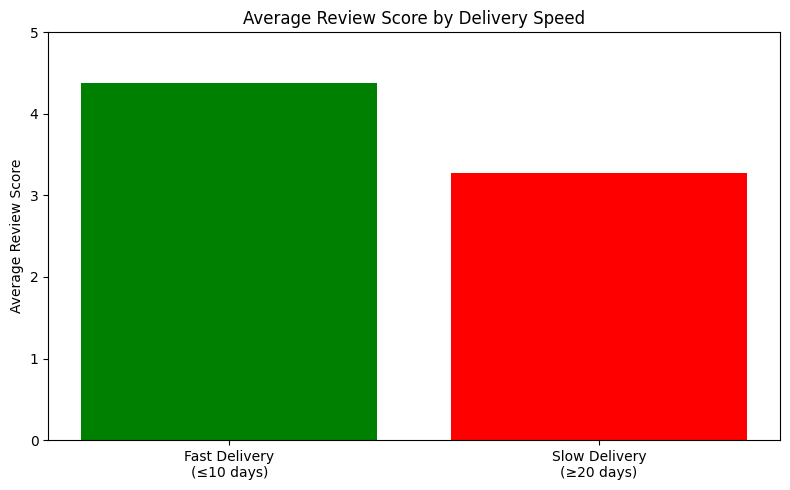

In [4]:
plt.figure(figsize=(8, 5))
plt.bar(['Fast Delivery\n(≤10 days)', 'Slow Delivery\n(≥20 days)'], 
        [group_a.mean(), group_b.mean()],
        color=['green', 'red'])
plt.title('Average Review Score by Delivery Speed')
plt.ylabel('Average Review Score')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()